In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


df = pd.read_csv("compiled_beehive_data.csv")

# 2. Define the columns we want to predict
# We exclude 'Name' and 'Timestamp' as they aren't predictive sensor data
target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge',
    'Temperature_Farenheit_Difference_C-E', 'Relative_Humidity_C-E',
    'Alive_or_Dead', 'Difference In Temperature From Empty Center',
    'Difference In Temperature From Empty Edge', 'Difference In Humidity From Empty Center',
    'Difference In Humidity From Empty Edge'
]

# 3. Create Lagged Features
# We want the features (X) to be 'Current' and the target (y) to be 'Next'
df_next = df.groupby('Name')[target_cols].shift(-1)
df_next.columns = [f"Next_{col}" for col in target_cols]

# Combine current and next values, then drop the last row of each hive (which has no 'Next')
combined = pd.concat([df, df_next], axis=1).dropna()

# 4. Split into Features (X) and Targets (y)
X = combined[target_cols]
y = combined[[f"Next_{col}" for col in target_cols]]

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Multi-Output Model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions, multioutput='raw_values')

print("--- Prediction Accuracy (Mean Absolute Error) ---")
for col, error in zip(target_cols, mae):
    print(f"{col}: {error:.4f}")

# 8. Function to predict the next state
def predict_next_state(current_row_df):
    """
    Takes a single row of current data and predicts the state 15 mins later
    """
    # Ensure columns are in the right order
    input_data = current_row_df[target_cols].values.reshape(1, -1)
    prediction = model.predict(input_data)
    return pd.DataFrame(prediction, columns=target_cols)

# Example usage:
# last_known_state = df.iloc[-1:]
# next_state = predict_next_state(last_known_state)
# print(next_state)

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. COMPILE & CLEAN (Strict Zero-Tolerance) ---
folder_path = 'data/Beehives_consolodated'
all_beehives = []

for filename in os.listdir(folder_path):
    if not filename.endswith(".csv"): continue
    
    df = pd.read_csv(os.path.join(folder_path, filename))
    # Clean headers and remove phantom columns
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    # Strict drop: any missing value = row deleted
    df = df.replace(r'^\s*$', pd.NA, regex=True).dropna(how='any').copy()
    
    if df.empty: continue

    ts_col = [c for c in df.columns if 'Timestamp' in c][0]
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(by=ts_col).drop_duplicates(subset=[ts_col])
    
    df.insert(0, "Name", filename.split(".")[0])
    all_beehives.append(df)

full_df = pd.concat(all_beehives, ignore_index=True)

# --- 2. TRAIN MULTI-OUTPUT MODEL ---
target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge',
    'Temperature_Farenheit_Difference_C-E', 'Relative_Humidity_C-E'
]

# Create Shifted targets (Predict T+15 using T+0)
df_next = full_df.groupby('Name')[target_cols].shift(-5)
df_next.columns = [f"Next_{col}" for col in target_cols]
model_data = pd.concat([full_df, df_next], axis=1).dropna()

X = model_data[target_cols]
y = model_data[[f"Next_{col}" for col in target_cols]]

model = LinearRegression()
model.fit(X, y)

# --- 3. LOOP THROUGH ALL HIVES AND PLOT ---
# Create a folder to store the results
output_folder = "beehive_plots"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

unique_hives = full_df['Name'].unique()
print(f"Found {len(unique_hives)} hives. Generating plots...")

for hive in unique_hives:
    # Filter data for this specific hive
    hive_data = model_data[model_data['Name'] == hive]
    
    if len(hive_data) < 2:
        print(f"Skipping {hive}: Not enough data points.")
        continue

    # Generate predictions
    preds = model.predict(hive_data[target_cols])
    
    # Create the Plot
    plt.figure(figsize=(14, 7))
    
    # Align the X-axis to the "Next" time point
    ts_col_name = [c for c in full_df.columns if 'Timestamp' in c][0]
    plot_time = full_df.groupby('Name')[ts_col_name].shift(-1).loc[hive_data.index]

    # Plot Temperature Actual vs Predicted
    plt.scatter(plot_time, hive_data['Next_Temperature_Fahrenheit'], 
                color='blue', label='Actual Temp', s=15, alpha=0.4)
    plt.plot(plot_time, preds[:, 0], # Index 0 is Temp
             color='red', label='LR Prediction', linewidth=1.5)

    plt.title(f'State Prediction for Hive: {hive}')
    plt.xlabel('Timestamp')
    plt.ylabel('Temperature (Fahrenheit)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=35)
    
    # Save the plot
    plt.tight_layout()
    plt.savefig(f"{output_folder}/prediction_{hive}.png")
    plt.close() # Close to free up memory

print(f"All plots saved in the '{output_folder}' directory.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('compiled_beehive_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge'
]

def create_windows(data, window_size=96, horizon=96):
    X, y = [], []

    for hive in data['Name'].unique():
        hive_df = data[data['Name'] == hive][target_cols].values
        
        for i in range(len(hive_df) - window_size - horizon + 1):
            # Input: Past 24 hours (96 samples * 4 features)
            X.append(hive_df[i : i + window_size].flatten())
            # Output: Next 24 hours (96 samples * 4 features)
            y.append(hive_df[i + window_size : i + window_size + horizon].flatten())
            
    return np.array(X), np.array(y)

WINDOW_SIZE = 96 
HORIZON = 96

# Clean data 
df = df.dropna(subset=target_cols)
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)
# 2. Windowing (using your existing function)
X, y = create_windows(df, WINDOW_SIZE, HORIZON)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=50, max_depth=5))
model.fit(X_train, y_train)


score = model.score(X_test, y_test)
print(f"Model R^2 Score: {score:.4f}")

import joblib


joblib.dump(model, 'beehive_model.joblib')
joblib.dump(scaler_X, 'scaler_X.joblib')
joblib.dump(scaler_y, 'scaler_y.joblib')
print("Model and scalers saved successfully.")

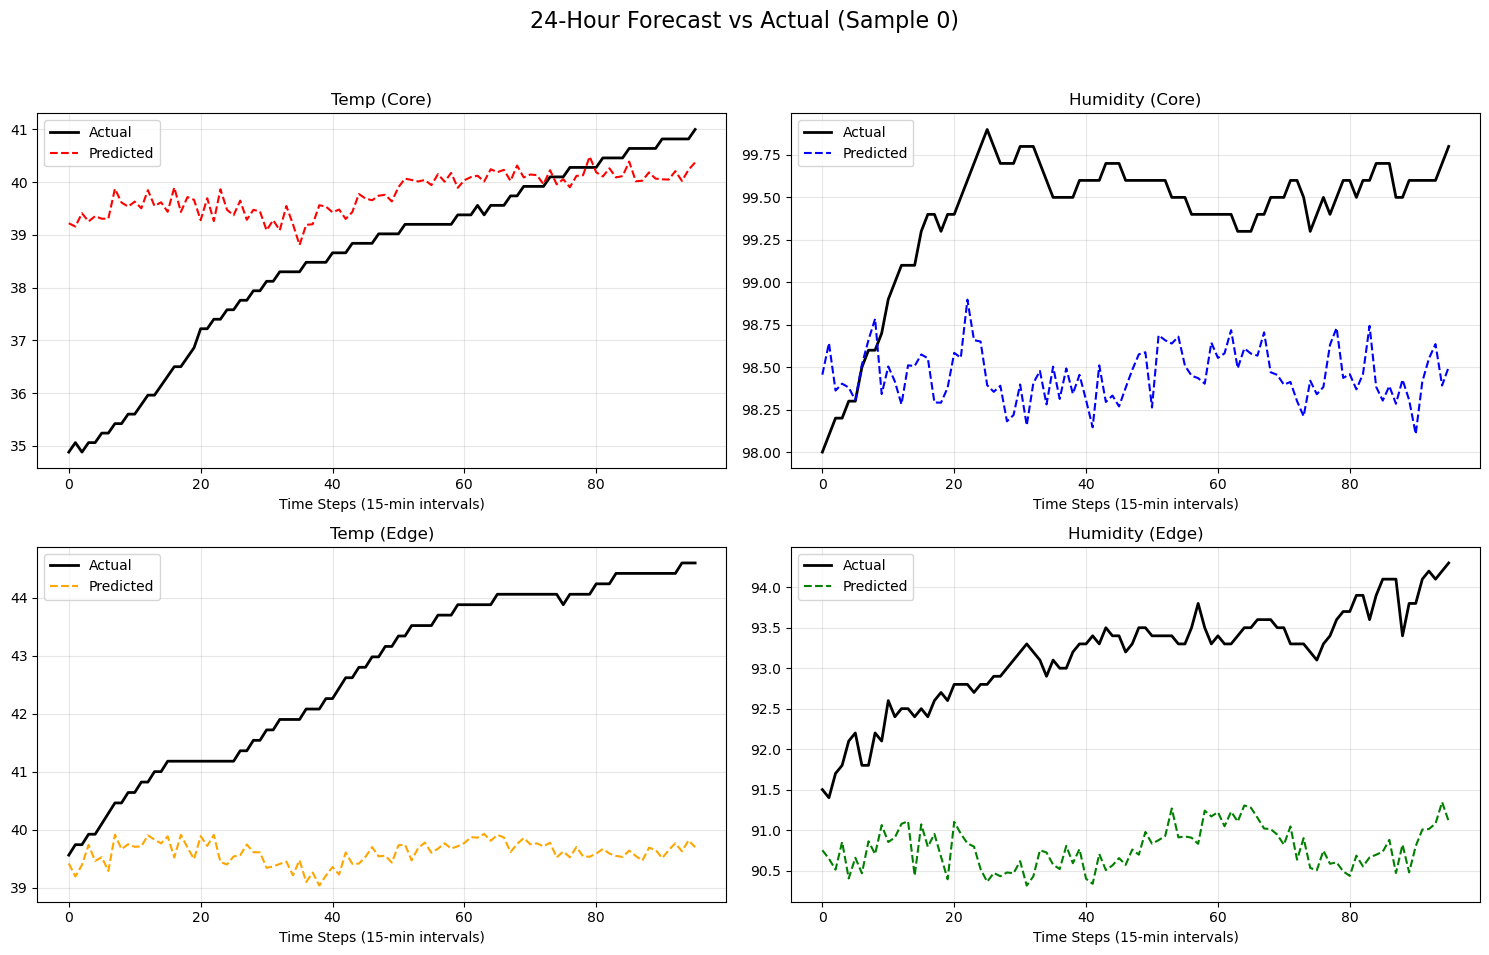

In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load everything back in
model = joblib.load('beehive_model.joblib')
scaler_X = joblib.load('scaler_X.joblib')
scaler_y = joblib.load('scaler_y.joblib')

y_pred_scaled = model.predict(X_test)

# 3. Inverse Scale the results to get real units (F and %)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled)
y_actual_rescaled = scaler_y.inverse_transform(y_test)

sample_idx = 0  # Change this to look at different windows
actual_sample = y_actual_rescaled[sample_idx].reshape(96, 4)
pred_sample = y_pred_rescaled[sample_idx].reshape(96, 4)

# 5. Plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'24-Hour Forecast vs Actual (Sample {sample_idx})', fontsize=16)

target_names = ['Temp (Core)', 'Humidity (Core)', 'Temp (Edge)', 'Humidity (Edge)']
colors = ['red', 'blue', 'orange', 'green']

for i, ax in enumerate(axes.flatten()):
    ax.plot(actual_sample[:, i], label='Actual', color='black', lw=2)
    ax.plot(pred_sample[:, i], label='Predicted', color=colors[i], linestyle='--')
    ax.set_title(target_names[i])
    ax.set_xlabel('Time Steps (15-min intervals)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import joblib

df = pd.read_csv('compiled_beehive_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge'
]

def create_windows(data, window_size=96, horizon=96):
    X, y = [], []

    for hive in data['Name'].unique():
        hive_df = data[data['Name'] == hive][target_cols].values
         
        for i in range(0,len(hive_df) - window_size - horizon + 1, 48):
            # Input: Past 24 hours (96 samples * 4 features)
            X.append(hive_df[i : i + window_size].flatten())
            # Output: Next 24 hours (96 samples * 4 features)
            y.append(hive_df[i + window_size : i + window_size + horizon].flatten())
            
    return np.array(X), np.array(y)

WINDOW_SIZE = 96 
HORIZON = 96


df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)

X, y = create_windows(df, WINDOW_SIZE, HORIZON)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=15, max_depth=2))
model.fit(X_train, y_train)


score = model.score(X_test, y_test)
print(f"Model R^2 Score: {score:.4f}")

joblib.dump(model, 'beehive_model.joblib')
joblib.dump(scaler_X, 'scaler_X.joblib')
joblib.dump(scaler_y, 'scaler_y.joblib')
print("Model and scalers saved successfully.")

Model R^2 Score: 0.8399
Model and scalers saved successfully.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import joblib

df = pd.read_csv('compiled_beehive_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

target_cols = [
    'Temperature_Fahrenheit', 'Relative_Humidity', 
    'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge'
]

def create_windows(data, window_size=96, horizon=96):
    X, y = [], []

    for hive in data['Name'].unique():
        hive_df = data[data['Name'] == hive][target_cols].values
         
        for i in range(0,len(hive_df) - window_size - horizon + 1, 48):
            # Input: Past 24 hours (96 samples * 4 features)
            X.append(hive_df[i : i + window_size].flatten())
            # Output: Next 24 hours (96 samples * 4 features)
            y.append(hive_df[i + window_size : i + window_size + horizon].flatten())
            
    return np.array(X), np.array(y)

WINDOW_SIZE = 96 
HORIZON = 96


df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)

X, y = create_windows(df, WINDOW_SIZE, HORIZON)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=15, max_depth=2))
model.fit(X_train, y_train)


score = model.score(X_test, y_test)
print(f"Model R^2 Score: {score:.4f}")

joblib.dump(model, 'beehive_model.joblib')
joblib.dump(scaler_X, 'scaler_X.joblib')
joblib.dump(scaler_y, 'scaler_y.joblib')
print("Model and scalers saved successfully.")

In [55]:
#use the day average dataset to predict the next day average state of the hive, and compare it to the actual next day average state. This will give us a more interpretable metric of how well our model is doing in terms of predicting the overall trend of the hive's state, rather than just the 15-minute intervals.
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
df = pd.read_csv('data\Daily_averages\daily_avg_WEE.csv')

X_daily = df.drop(columns=['Date', 'Alive_or_Dead']).dropna() 
X_daily = X_daily[:-1]
y_daily = df[['Temperature_Fahrenheit', 'Relative_Humidity', 'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge']].shift(-1)[:-1]

X_train_daily, X_test_daily, y_train_daily, y_test_daily = train_test_split(X_daily, y_daily, test_size=0.2, random_state=42)

model_daily = MultiOutputRegressor(RandomForestRegressor(n_estimators=150, max_depth=50))

model_daily.fit(X_train_daily, y_train_daily)
score_daily = model_daily.score(X_test_daily, y_test_daily)
X_test = pd.read_csv('data\Daily_averages\daily_avg_WBC.csv')
X_test = X_test.drop(columns=['Date', 'Alive_or_Dead']).dropna()
X_test = X_test[:-1]
y_test = pd.read_csv('data\Daily_averages\daily_avg_WBC.csv')
y_test = y_test[['Temperature_Fahrenheit', 'Relative_Humidity', 'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge']].dropna()
y_test = y_test.shift(-1)[:-1]
print(f"Daily Average Model R^2 Score: {score_daily:.4f}")
model_daily = MultiOutputRegressor(LinearRegression())
model_daily.fit(X_train_daily, y_train_daily)
score_daily = model_daily.score(X_test_daily, y_test_daily)
f1 = model_daily.score(X_test_daily, y_test_daily)
print(f"F1 Score: {f1:.4f}")
print(f"Daily Average Model R^2 Score: {score_daily:.4f}")

joblib.dump(model_daily, 'beehive_model_dalily_linreg.joblib')
print("Model and scalers saved successfully.")
#feed in average ambient conditions from the dead box

<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
C:\Users\vitya\AppData\Local\Temp\ipykernel_12608\4021553222.py:10: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('data\Daily_averages\daily_avg_WEE.csv')
C:\Users\vitya\AppData\Local\Temp\ipykernel_12608\4021553222.py:22: SyntaxWarning: invalid escape sequence '\D'
  X_test = pd.read_csv('data\Daily_averages\daily_avg_WBC.csv')
C:\Users\vitya\AppData\Local\Temp\ipykernel_12608\4021553222.py:25: SyntaxWarning: invalid escape sequence '\D'
  y_test = pd.read_csv('data\Daily_averages\daily_avg_WBC.csv')


Daily Average Model R^2 Score: 0.6536
F1 Score: 0.7295
Daily Average Model R^2 Score: 0.7295
Model and scalers saved successfully.


<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
C:\Users\vitya\AppData\Local\Temp\ipykernel_12608\2700224053.py:17: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('data\Daily_averages\all_daily_averages.csv')
C:\Users\vitya\AppData\Local\Temp\ipykernel_12608\2700224053.py:17: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('data\Daily_averages\all_daily_averages.csv')


OSError: [Errno 22] Invalid argument: 'data\\Daily_averages\x07ll_daily_averages.csv'

F1 Score for Temperature_Fahrenheit: 0.7295
R^2 Score for Temperature_Fahrenheit: 0.7295
F1 Score for Relative_Humidity: 0.7295
R^2 Score for Relative_Humidity: 0.7295
F1 Score for Temperature_Farenheit_Edge: 0.7295
R^2 Score for Temperature_Farenheit_Edge: 0.7295
F1 Score for Relative_Humidity_Edge: 0.7295
R^2 Score for Relative_Humidity_Edge: 0.7295


<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\vitya\AppData\Local\Temp\ipykernel_12608\835794400.py:5: SyntaxWarning: invalid escape sequence '\D'
  df_new = pd.read_csv('data\Daily_averages\daily_avg_WGE.csv')


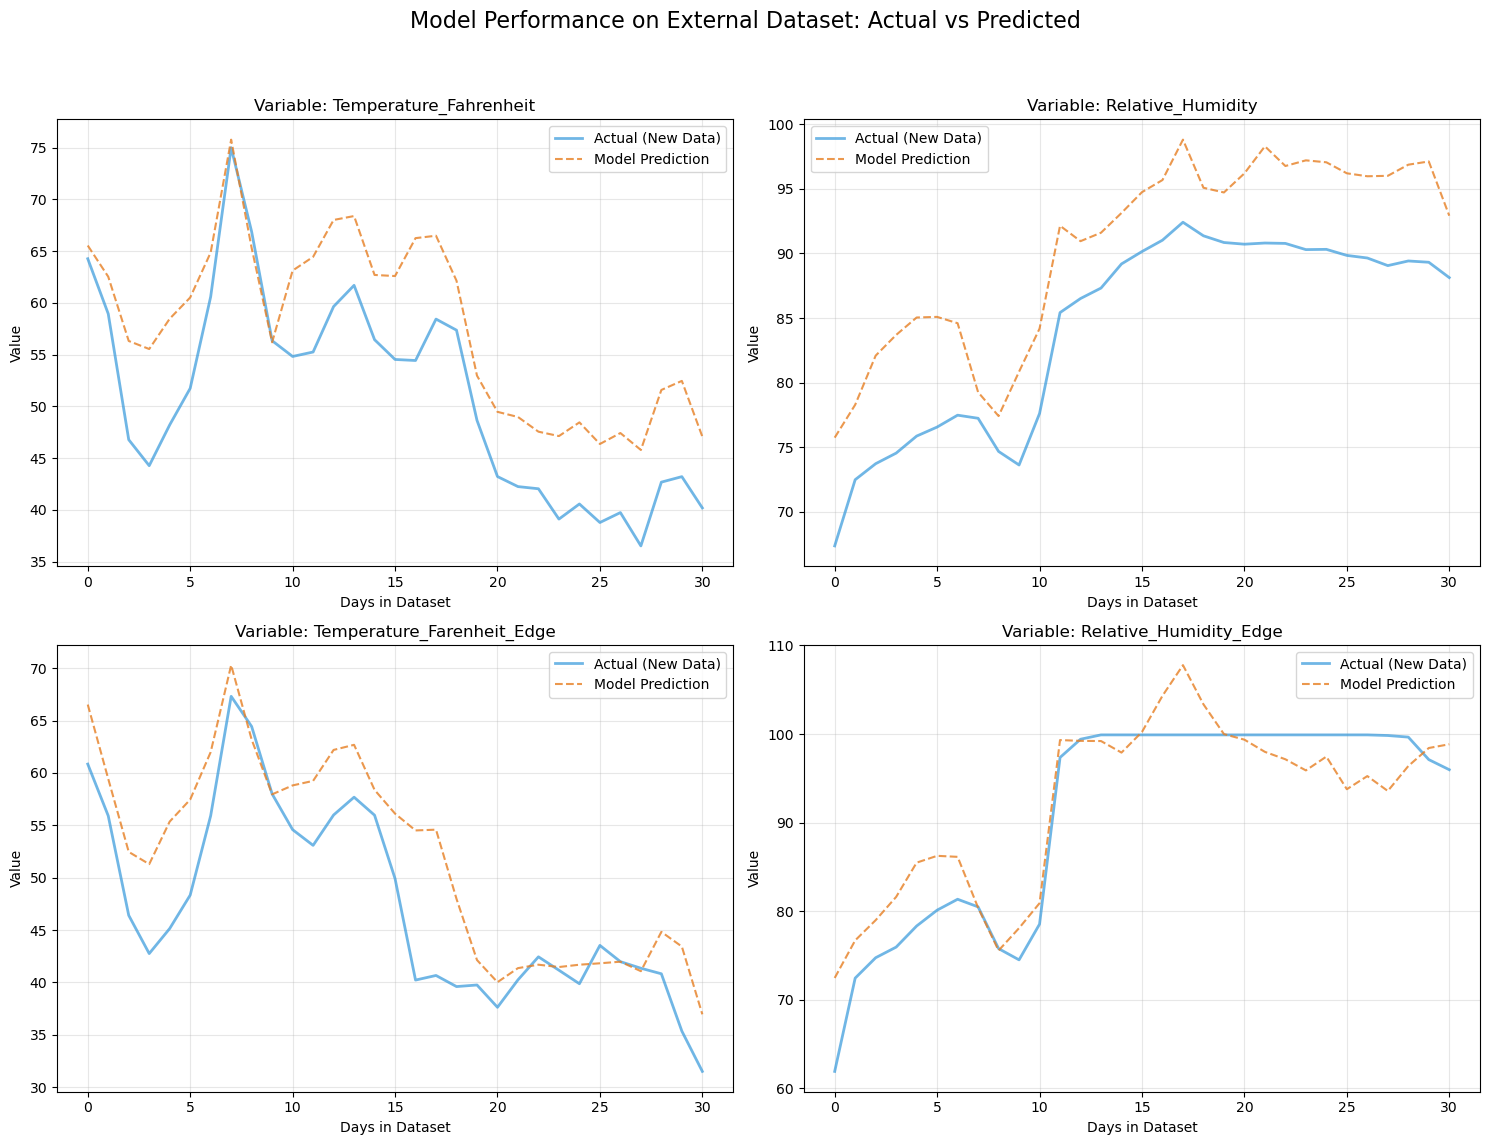

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df_new = pd.read_csv('data\Daily_averages\daily_avg_WGE.csv') 
df_new.dropna(inplace=True)

X_new = df_new.drop(columns=['Date', 'Alive_or_Dead']).dropna()
y_new_actual = df_new[['Temperature_Fahrenheit', 'Relative_Humidity', 'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge']].dropna()

#make the test data be the next day's average conditions, and the model's predictions be the predicted next day's average conditions based on the 

y_pred_new = model_daily.predict(X_new)
y_pred_df = pd.DataFrame(y_pred_new, columns=y_new_actual.columns, index=y_new_actual.index)

plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance on External Dataset: Actual vs Predicted', fontsize=16)

columns = y_new_actual.columns

for i, col in enumerate(columns):
    ax = axes[i//2, i%2]
    
    actual = y_new_actual[col].sort_index()
    predicted = y_pred_df[col].sort_index()
    
    f1 = model_daily.score(X_test_daily, y_test_daily)
    print(f"F1 Score for {col}: {f1:.4f}")
    r2 = model_daily.score(X_test_daily, y_test_daily)
    print(f"R^2 Score for {col}: {r2:.4f}")
    ax.plot(actual.values, label='Actual (New Data)', color='#3498db', alpha=0.7, linewidth=2)
    ax.plot(predicted.values, label='Model Prediction', color='#e67e22', linestyle='--', alpha=0.8)
    
    ax.set_title(f'Variable: {col}')
    ax.set_xlabel('Days in Dataset')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()